# Proposed methods: domain adaptation targeting conditional shift

## Diagnosis — why did existing DA not work?

| Existing method | What it optimises | Relation to the results (3.4) |
|---|---|---|
| MMD · CORAL · DANN · CDAN | align the marginal distribution P(x) | the P(x) gap is almost the same for the three endpoints (MMD 0.30–0.33, domain AUC 0.93–0.96) → this axis cannot create differences between endpoints |
| Importance Weighting | weight the source by the density ratio p_t(x)/p_s(x) | the weighting criterion lives in **input space**. The axis that actually separates the endpoints is label correspondence (1-NN ρ: f_u 0.70 / CL 0.19 / t½ 0.05) |

In other words, all five methods looked at **where** source molecules are, never at whether those source labels **actually transfer**.
The problem is not marginal shift but **conditional shift P(y|x)**.

## Proposed methods

| Method | Existing DA it builds on | Key change |
|---|---|---|
| **CMMD** | MMD (JAN/DSAN family) | measures MMD with a joint feature–label kernel. As σ_y → ∞ it **becomes exactly the existing MMD** |
| **CDAN-mm** | CDAN | the domain classifier input becomes the original paper's multilinear map `f ⊗ [ŷ,1]` (the existing implementation used sigmoid(\|ŷ\|) confidence weighting) |
| **LCW** | Importance Weighting | weights = `relevance × correspondence` instead of the density ratio. Decomposed into **LCW-rel** (relevance only = same criterion as IW) and **LCW-corr** (correspondence only) |

Transfer-learning reference points run alongside (not DA, for comparison):
- **IVP** : inject the source model's in vitro prediction into the target head (learned IVIVE)
- **PTFT** : pretrain the encoder on source labels, then fine-tune on the target (frozen-embedding version of notebook 10)
- **-shuffled** : control with shuffled source labels. Same molecules, no label information → tells whether a gain comes from the labels

## Shared conventions
Same as 01–08: same scaffold 5-fold and inner val split, val R² early stopping, AdamW(1e-3, 1e-4), Huber(δ=1), batch 32, seed = seed×100+fold.
Hyperparameters are selected by fold-mean **val R²** (exploration stage, seed 0), and the final run **fixes** those values over 10 seeds.
Correspondence weights use target **train** labels only (no test leakage).

> **The reference is `TargetOnly`** — the same architecture as the proposed methods, without using the source.
> The `Baseline` of 08 has a single linear head layer, so its architecture differs and it cannot be compared directly.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, t as t_dist

ROOT = r'..'
RES = os.path.join(ROOT, 'results')
PROP_DIR = os.path.join(RES, 'proposed')

PROPS = ['fu', 'clearance', 'half_life']              # ordered by mechanistic distance
LABEL = {'fu': 'f_u', 'clearance': 'CL', 'half_life': 't½'}
COLOR = {'fu': '#1a7f37', 'clearance': '#0969da', 'half_life': '#cf222e'}

TAG = '_final' if os.path.exists(os.path.join(PROP_DIR, 'runs_final.csv')) else '_explore'
runs = pd.read_csv(os.path.join(PROP_DIR, f'runs{TAG}.csv'))
best_hp = json.load(open(os.path.join(PROP_DIR, f'best_hp{TAG}.json')))
N_SEED = runs['seed'].nunique()
print(f'Results: runs{TAG}.csv   |  {N_SEED} seeds × 5 folds × {runs.property.nunique()} endpoints')
print('Methods:', list(runs['method'].unique()))

pd.set_option('display.width', 220)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True})


def holm(p):
    p = np.asarray(p, float)
    adj, running = np.full_like(p, np.nan), 0.0
    ok = np.where(~np.isnan(p))[0]
    for rank, i in enumerate(ok[np.argsort(p[ok])]):
        running = max(running, min(1.0, (len(ok) - rank) * p[i]))
        adj[i] = running
    return adj

Results: runs_final.csv   |  10 seeds × 5 folds × 3 endpoints
Methods: ['TargetOnly', 'CMMD', 'LCW', 'LCW-rel', 'LCW-corr', 'IVP', 'PTFT', 'IVP-shuffled', 'PTFT-shuffled']


## 1. Selected hyperparameters

**Look at CMMD's σ_y first.** The grid maximum (4.0) gives k_y ≈ 1, i.e. effectively the existing marginal MMD.
So **if σ_y was chosen below 4.0, validation preferred conditional over marginal alignment**.

In [2]:
hp_rows = []
for p in PROPS:
    for m, hp in best_hp[p].items():
        if m in runs['method'].unique() and hp:
            hp_rows.append({'endpoint': LABEL[p], 'method': m, **hp})
hp_table = pd.DataFrame(hp_rows)
display(hp_table.set_index(['endpoint', 'method']))

cm = hp_table[hp_table['method'] == 'CMMD']
if len(cm):
    print('\nCMMD σ_y (grid 0.25 / 0.5 / 1.0 / 4.0, 4.0 ≈ existing marginal MMD):')
    for _, r in cm.iterrows():
        tag = '← marginal (same as existing MMD)' if r['sigma_y'] >= 4.0 else '← conditional'
        print(f"  {r['endpoint']:<4} σ_y = {r['sigma_y']:<5} {tag}")

lam  tau  sigma_y
endpoint method                     
f_u      LCW       1.0  1.0      NaN
         LCW-rel   0.3  1.0      NaN
         LCW-corr  1.0  2.0      NaN
         CMMD      0.1  NaN     1.00
CL       LCW       1.0  1.0      NaN
         LCW-rel   1.0  1.0      NaN
         LCW-corr  1.0  0.5      NaN
         CMMD      1.0  NaN     0.50
t½       LCW       1.0  1.0      NaN
         LCW-rel   0.3  1.0      NaN
         LCW-corr  0.1  0.5      NaN
         CMMD      0.1  NaN     0.25


CMMD σ_y (grid 0.25 / 0.5 / 1.0 / 4.0, 4.0 ≈ existing marginal MMD):
  f_u  σ_y = 1.0   ← conditional
  CL   σ_y = 0.5   ← conditional
  t½   σ_y = 0.25  ← conditional


## 2. Performance vs TargetOnly

Seed mean per fold, then a paired t-test against TargetOnly (n = 5 folds). Same test as 08.
`p_holm` is the Holm-corrected value over all (method × endpoint) comparisons in the table.

In [3]:
ORDER = ['TargetOnly', 'CMMD', 'CDAN-mm', 'LCW', 'LCW-rel', 'LCW-corr',
         'IVP', 'IVP-shuffled', 'PTFT', 'PTFT-shuffled', 'PTFT+LCW', 'PTFT+IVP']
METHODS = [m for m in ORDER if m in runs['method'].unique()]

fold_mean = runs.groupby(['property', 'method', 'fold'])[['r2', 'rho', 'rmse']].mean()


def delta(prop, method, col='r2'):
    a = fold_mean.loc[(prop, method)][col]
    b = fold_mean.loc[(prop, 'TargetOnly')][col]
    d = a - b
    half = t_dist.ppf(0.975, len(d) - 1) * d.std(ddof=1) / np.sqrt(len(d))
    return d.mean(), half, ttest_rel(a, b).pvalue


rows = []
for m in METHODS:
    for p in PROPS:
        r2 = fold_mean.loc[(p, m)]['r2'].mean()
        row = {'endpoint': LABEL[p], 'method': m, 'R²': r2,
               'ρ': fold_mean.loc[(p, m)]['rho'].mean()}
        if m != 'TargetOnly':
            d, half, pv = delta(p, m)
            row.update({'ΔR²': d, 'CI_lo': d - half, 'CI_hi': d + half, 'p': pv})
        rows.append(row)
perf = pd.DataFrame(rows)
perf['p_holm'] = holm(perf['p'])
perf.to_csv(os.path.join(PROP_DIR, f'summary_table{TAG}.csv'), index=False, encoding='utf-8-sig')

perf.pivot(index='method', columns='endpoint', values=['R²', 'ΔR²', 'p']).reindex(METHODS)[
    [(c, LABEL[p]) for c in ['R²', 'ΔR²', 'p'] for p in PROPS]].round(4)

R²                     ΔR²                       p                
endpoint          f_u      CL      t½     f_u      CL      t½     f_u      CL      t½
method                                                                               
TargetOnly     0.2251  0.0959  0.0841     NaN     NaN     NaN     NaN     NaN     NaN
CMMD           0.2436  0.0798  0.0951  0.0185 -0.0162  0.0110  0.2450  0.0723  0.4044
LCW            0.2453  0.0928  0.0848  0.0202 -0.0032  0.0007  0.2716  0.4120  0.9443
LCW-rel        0.2375  0.0849  0.0896  0.0124 -0.0110  0.0055  0.4436  0.1697  0.6987
LCW-corr       0.2458  0.0929  0.0824  0.0207 -0.0031 -0.0017  0.2413  0.7400  0.7799
IVP            0.2505  0.0955  0.0857  0.0254 -0.0005  0.0016  0.2625  0.9117  0.9002
IVP-shuffled   0.2153  0.0987  0.0862 -0.0098  0.0027  0.0021  0.3351  0.5689  0.8317
PTFT           0.3000  0.0770  0.0890  0.0749 -0.0190  0.0049  0.0359  0.1016  0.7281
PTFT-shuffled  0.2238  0.1004  0.0961 -0.0013  0.0045  0.0120  0.9398  0.6133  0.4547

### 2.1 Side by side with existing DA — f_u

The five existing DA methods come from `results/significance_mae` (10 seeds, relative to the 08 Baseline).
The two experiments have different reference models (08 uses the linear-head Baseline, here TargetOnly), so **only ΔR²** is compared.

In [4]:
sig = pd.read_csv(os.path.join(RES, 'significance', 'summary.csv')) \
    if not os.path.exists(os.path.join(RES, 'significance_mae', 'summary.csv')) \
    else pd.read_csv(os.path.join(RES, 'significance_mae', 'summary.csv'))
old = sig[sig['method'] != 'Baseline'][['property', 'method', 'delta_r2']].copy()
old['group'] = 'existing DA (vs Baseline, 10 seeds)'

new = perf[perf['method'] != 'TargetOnly'][['endpoint', 'method', 'ΔR²']].copy()
new.columns = ['endpoint', 'method', 'delta_r2']
new['group'] = f'this work (vs TargetOnly, {N_SEED} seeds)'
old['endpoint'] = old['property'].map(LABEL)

comp = pd.concat([old[['endpoint', 'method', 'delta_r2', 'group']], new], ignore_index=True)
comp.pivot_table(index=['group', 'method'], columns='endpoint', values='delta_r2')[
    [LABEL[p] for p in PROPS]].round(4)

endpoint                                                     f_u      CL      t½
group                               method                                      
existing DA (vs Baseline, 10 seeds) CDAN                  0.0134  0.0093  0.0017
                                    CORAL                -0.0014 -0.0007  0.0037
                                    DANN                 -0.0153 -0.0068 -0.0004
                                    Importance Weighting -0.0078  0.0015  0.0049
                                    MMD                  -0.0158 -0.0023 -0.0004
this work (vs TargetOnly, 10 seeds) CMMD                  0.0185 -0.0162  0.0110
                                    IVP                   0.0254 -0.0005  0.0016
                                    IVP-shuffled         -0.0098  0.0027  0.0021
                                    LCW                   0.0202 -0.0032  0.0007
                                    LCW-corr              0.0207 -0.0031 -0.0017
                                    LCW-rel               0.0124 -0.0110  0.0055
                                    PTFT                  0.0749 -0.0190  0.0049
                                    PTFT-shuffled        -0.0013  0.0045  0.0120

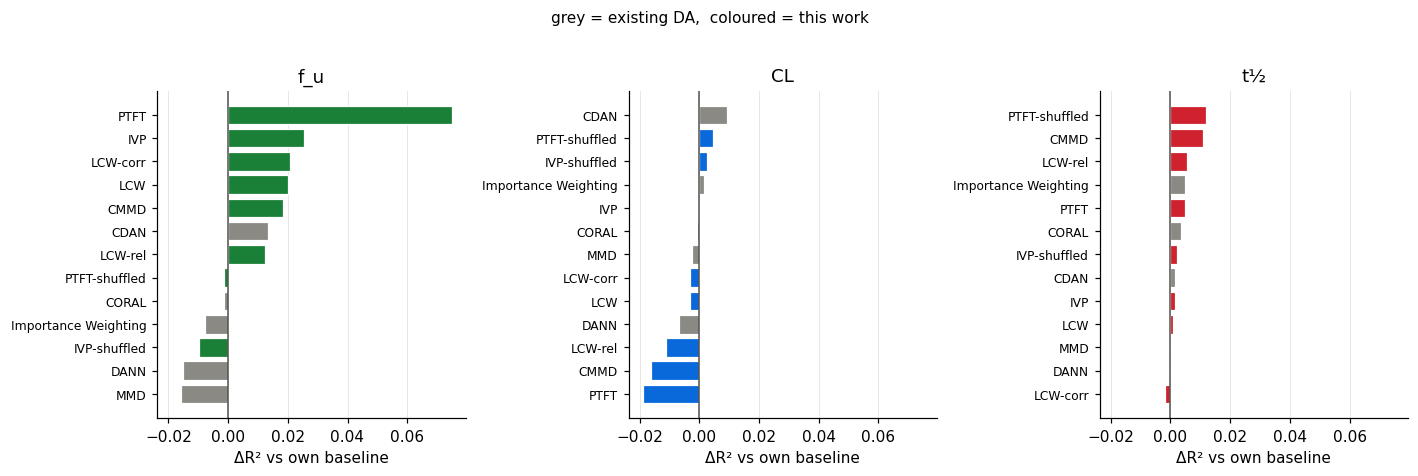

In [5]:
fig, axes = plt.subplots(1, len(PROPS), figsize=(13, 4.2), sharex=True)
for ax, p in zip(axes, PROPS):
    d = comp[comp['endpoint'] == LABEL[p]].sort_values('delta_r2')
    colors = ['#8a8984' if g.startswith('existing') else COLOR[p] for g in d['group']]
    ax.barh(range(len(d)), d['delta_r2'], color=colors, edgecolor='white', linewidth=0.8)
    ax.set_yticks(range(len(d)))
    ax.set_yticklabels(d['method'], fontsize=8)
    ax.axvline(0, color='#52514e', lw=1)
    ax.set_title(LABEL[p])
    ax.set_xlabel('ΔR² vs own baseline')
    ax.grid(axis='y', visible=False)
fig.suptitle('grey = existing DA,  coloured = this work', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

## 3. Forest plot — ΔR² and 95% CI

Only methods whose CI excludes 0 can be said to "improve".

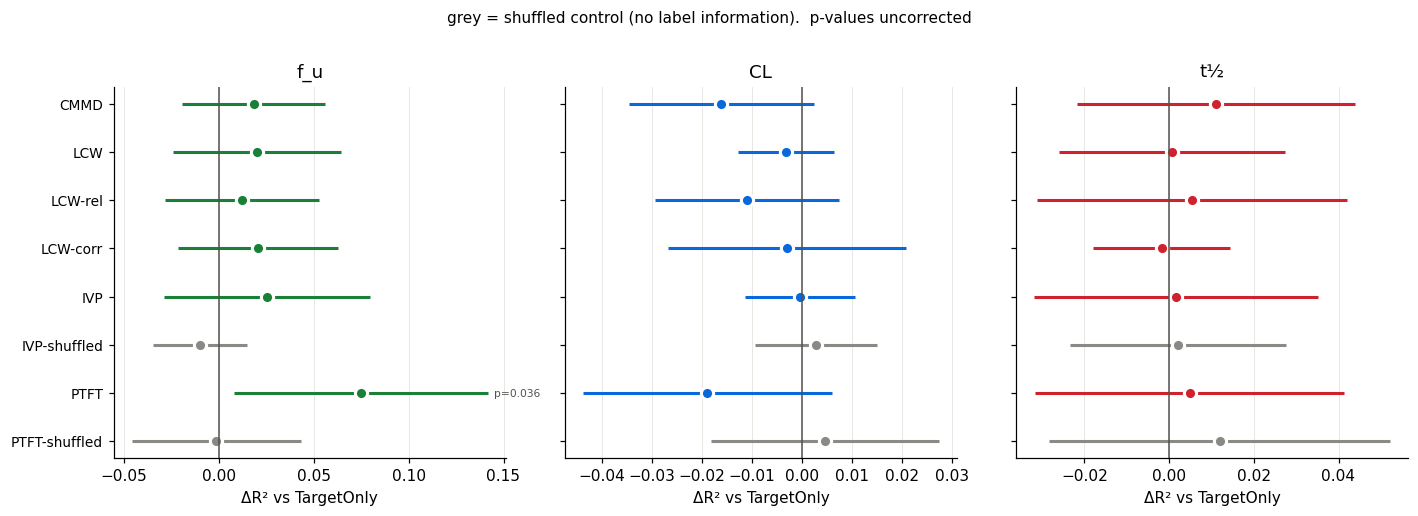

In [6]:
fig, axes = plt.subplots(1, len(PROPS), figsize=(13, 4.6), sharey=True)
plot_m = [m for m in METHODS if m != 'TargetOnly']
for ax, p in zip(axes, PROPS):
    for i, m in enumerate(plot_m):
        d, half, pv = delta(p, m)
        y = len(plot_m) - 1 - i
        c = '#8a8984' if m.endswith('-shuffled') else COLOR[p]
        ax.hlines(y, d - half, d + half, color=c, lw=2)
        ax.plot(d, y, 'o', ms=8, color=c, mec='white', mew=2)
        if pv < 0.05:
            ax.annotate(f'p={pv:.3f}', (d + half, y), xytext=(4, 0), textcoords='offset points',
                        va='center', fontsize=7, color='#52514e')
    ax.axvline(0, color='#52514e', lw=1)
    ax.set_yticks(range(len(plot_m)))
    ax.set_yticklabels(plot_m[::-1], fontsize=9)
    ax.set_title(LABEL[p])
    ax.set_xlabel('ΔR² vs TargetOnly')
    ax.grid(axis='y', visible=False)
fig.suptitle('grey = shuffled control (no label information).  p-values uncorrected', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## 4. Pure contribution of label information — shuffled controls

`-shuffled` trains with randomly shuffled source labels. The molecules are unchanged, so
only the **"representation-learning effect of exposure to extra molecules"** remains, **without label information**.

    Pure contribution of label information = Δ(real) − Δ(shuffled)

If the shuffled Δ is above 0, part of the gain comes from data quantity rather than from in vitro labels.

,,Δ real,Δ shuffled,label contribution,label contribution ratio,p (real vs shuffled)
endpoint,method,,,,,
f_u,IVP,0.0254,-0.0098,0.0352,1.3854,0.1665
CL,IVP,-0.0005,0.0027,-0.0032,NaN,0.4181
t½,IVP,0.0016,0.0021,-0.0005,-0.2901,0.9307
f_u,PTFT,0.0749,-0.0013,0.0762,1.0172,0.0685
CL,PTFT,-0.0190,0.0045,-0.0235,NaN,0.1168
t½,PTFT,0.0049,0.0120,-0.0071,-1.4431,0.6396


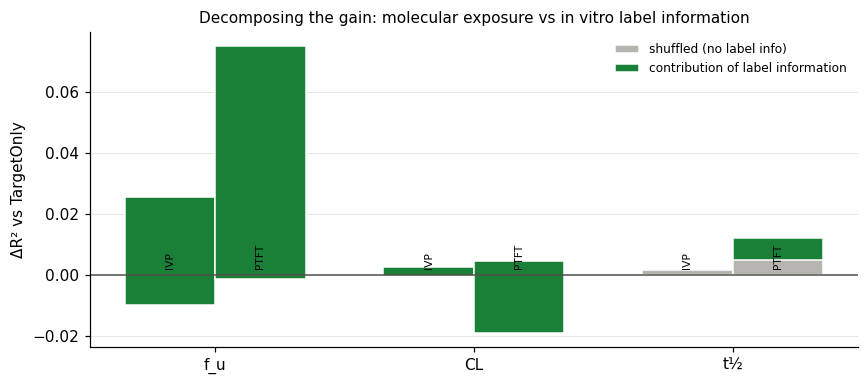

In [7]:
pairs = [(m, m + '-shuffled') for m in ('IVP', 'PTFT') if m + '-shuffled' in METHODS]
rows = []
for real, sh in pairs:
    for p in PROPS:
        dr = delta(p, real)[0]
        ds = delta(p, sh)[0]
        a = fold_mean.loc[(p, real)]['r2']
        b = fold_mean.loc[(p, sh)]['r2']
        rows.append({'endpoint': LABEL[p], 'method': real,
                     'Δ real': dr, 'Δ shuffled': ds, 'label contribution': dr - ds,
                     'label contribution ratio': (dr - ds) / dr if dr > 0 else np.nan,
                     'p (real vs shuffled)': ttest_rel(a, b).pvalue})
contrib = pd.DataFrame(rows)
display(contrib.set_index(['endpoint', 'method']).round(4))

if len(contrib):
    fig, ax = plt.subplots(figsize=(8, 3.6))
    w, xs = 0.35, np.arange(len(PROPS))
    for i, (real, _) in enumerate(pairs):
        c = contrib[contrib['method'] == real].set_index('endpoint').loc[[LABEL[p] for p in PROPS]]
        ax.bar(xs + (i - 0.5) * w, c['Δ shuffled'], width=w, color='#b5b4ae',
               edgecolor='white', label='shuffled (no label info)' if i == 0 else None)
        ax.bar(xs + (i - 0.5) * w, c['label contribution'], width=w, bottom=c['Δ shuffled'],
               color='#1a7f37', edgecolor='white', label='contribution of label information' if i == 0 else None)
        for j, ep in enumerate([LABEL[p] for p in PROPS]):
            ax.text(xs[j] + (i - 0.5) * w, 0.002, real, ha='center', va='bottom', fontsize=7, rotation=90)
    ax.axhline(0, color='#52514e', lw=1)
    ax.set_xticks(xs)
    ax.set_xticklabels([LABEL[p] for p in PROPS])
    ax.set_ylabel('ΔR² vs TargetOnly')
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis='x', visible=False)
    ax.set_title('Decomposing the gain: molecular exposure vs in vitro label information', fontsize=10)
    plt.tight_layout()
    plt.show()

## 5. LCW decomposition — which term contributes?

`w = relevance × correspondence`

- **LCW-rel** : relevance only → **input-space** criterion like IW
- **LCW-corr**: correspondence only → **label-correspondence** criterion
- **LCW** : the product of the two

If LCW-corr > LCW-rel, switching the weighting criterion from input space to label correspondence actually helped.

,f_u,CL,t½
LCW,0.0202,-0.0032,0.0007
LCW-rel,0.0124,-0.0110,0.0055
LCW-corr,0.0207,-0.0031,-0.0017


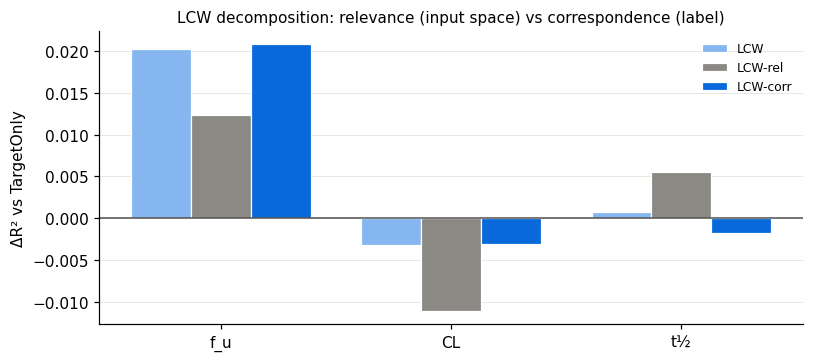

In [8]:
lcw = [m for m in ('LCW', 'LCW-rel', 'LCW-corr') if m in METHODS]
if lcw:
    tab = pd.DataFrame({LABEL[p]: {m: delta(p, m)[0] for m in lcw} for p in PROPS})
    display(tab.round(4))
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    w, xs = 0.26, np.arange(len(PROPS))
    for i, m in enumerate(lcw):
        ax.bar(xs + (i - 1) * w, [tab.loc[m, LABEL[p]] for p in PROPS], width=w,
               edgecolor='white', linewidth=0.8, label=m,
               color=['#86b6ef', '#8a8984', '#0969da'][i])
    ax.axhline(0, color='#52514e', lw=1)
    ax.set_xticks(xs)
    ax.set_xticklabels([LABEL[p] for p in PROPS])
    ax.set_ylabel('ΔR² vs TargetOnly')
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis='x', visible=False)
    ax.set_title('LCW decomposition: relevance (input space) vs correspondence (label)', fontsize=10)
    plt.tight_layout()
    plt.show()

## 6. Gain vs label correspondence

Places each method's ΔR² per endpoint against the 1-NN label correspondence (Tanimoto ≥ 0.4) measured in 3.2.
With only three endpoints, **no regression line or correlation coefficient is computed** — read the direction only.

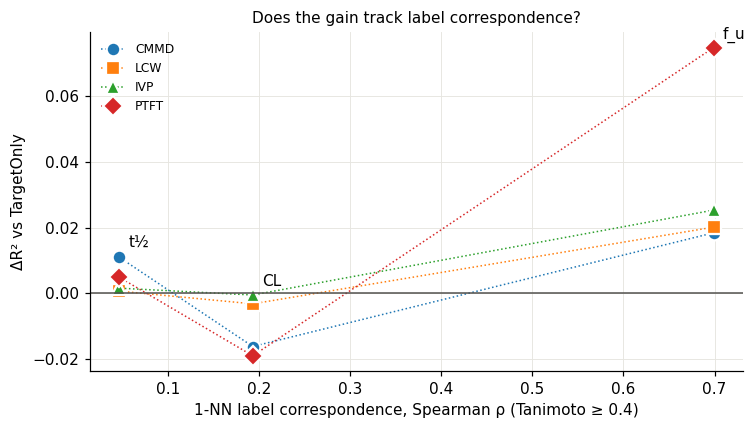

In [9]:
p4_path = os.path.join(ROOT, 'benchmark', 'results', 'phase_04_label_correspondence.json')
if os.path.exists(p4_path):
    p4 = json.load(open(p4_path))
    show = [m for m in ('CMMD', 'LCW', 'IVP', 'PTFT') if m in METHODS]
    fig, ax = plt.subplots(figsize=(7, 4))
    marks = dict(zip(show, ['o', 's', '^', 'D']))
    for m in show:
        xs_ = [p4[p]['spearman_rho'] for p in PROPS]
        ys_ = [delta(p, m)[0] for p in PROPS]
        ax.plot(xs_, ys_, marks[m], ms=9, mec='white', mew=1.5, label=m, ls=':', lw=1)
    for p in PROPS:
        ax.annotate(LABEL[p], (p4[p]['spearman_rho'], max(delta(p, m)[0] for m in show)),
                    xytext=(6, 6), textcoords='offset points', fontsize=10)
    ax.axhline(0, color='#52514e', lw=1)
    ax.set_xlabel('1-NN label correspondence, Spearman ρ (Tanimoto ≥ 0.4)')
    ax.set_ylabel('ΔR² vs TargetOnly')
    ax.legend(fontsize=8, frameon=False)
    ax.set_title('Does the gain track label correspondence?', fontsize=10)
    plt.tight_layout()
    plt.show()

## 7. Caveats for interpretation

1. **Multiple comparisons** — several methods were explored before the promising ones were run in full. Report against `p_holm`;
   use uncorrected p only for reference. Choosing methods in the exploration stage (3 seeds) is itself a selection bias,
   so final claims rest only on the confirmatory run (10 seeds).
2. **Power** — n for the paired test is 5 folds. More seeds only reduce the variance of the per-fold means; n stays the same.
3. **Shuffled controls** — if Δ(shuffled) is above 0, that much is a data-quantity effect, not label information.
   Any claimed gain of a proposed method must clear this line.
4. **Reference** — ΔR² in this notebook is relative to `TargetOnly`, in 08 relative to `Baseline` (linear head).
   Do not compare absolute R² directly; compare ΔR² only.
5. **Frozen embeddings** — PTFT here is MLP-level pretraining. It is a different experiment from notebook 10, which
   fine-tunes the upper Graphormer layers; do not report the two mixed under the same numbers.